
<h1><center><font size=10>Data Science and Business Analytics</center></font></h1>
<h1><center>PDS Coded Project</center></h1>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns



dekh basicallyu aa badhii python dataa visualization mateni cheee badhi imp libraries aagar samjhay

##Coded Project : Austo Automobile


In [6]:
data = pd.read_csv('/content/austo_automobile+%282%29+%281%29.csv')


In [7]:
data.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.0+ KB


In [9]:
data.shape


(1581, 14)

In [10]:
data.columns


Index(['Age', 'Gender', 'Profession', 'Marital_status', 'Education',
       'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working',
       'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make'],
      dtype='object')

In [11]:
 data.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1475.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,20225.559322,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19573.149277,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25600.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38300.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


In [12]:
data.dtypes


,0
Age,int64
Gender,object
Profession,object
Marital_status,object
Education,object
No_of_Dependents,int64
Personal_loan,object
House_loan,object
Partner_working,object
Salary,int64


In [13]:
data.isnull().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


In [14]:
print(data['Gender'].value_counts(dropna=False))

# Correct misspelled 'Female' entries
data['Gender'] = data['Gender'].replace({'Femle': 'Female', 'Femal': 'Female'})

# Verifing correction
print("\nAfter correction:")
print(data['Gender'].value_counts(dropna=False))

Gender
Male      1199
Female     327
NaN         53
Femal        1
Femle        1
Name: count, dtype: int64

After correction:
Gender
Male      1199
Female     329
NaN         53
Name: count, dtype: int64


In [15]:
missing_gender = data['Gender'].isna().sum()
missing_gender

53

In [16]:
missing_partner_salary = data['Partner_salary'].isna().sum()

In [17]:
gender_missing_pct = (missing_gender / len(data)) * 100
partner_salary_missing_pct = (missing_partner_salary / len(data)) * 100
print("\nAfter correction:")
print(data['Gender'].value_counts(dropna=False))
gender_missing_pct


After correction:
Gender
Male      1199
Female     329
NaN         53
Name: count, dtype: int64


3.3523086654016447

In [18]:
data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)
# data['Partner_salary'].fillna(0, inplace=True)
# Fill missing 'Partner_salary' with 0
print("\nAfter correction:")
print(data['Gender'].value_counts(dropna=False))
gender_missing_pct
data['Partner_salary'] = data['Partner_salary'].fillna(0)

# Recalculate 'Total_salary'
data['Total_salary'] = data['Salary'] + data['Partner_salary']



After correction:
Gender
Male      1252
Female     329
Name: count, dtype: int64


<ipython-input-18-bb990b61bca4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna(data['Gender'].mode()[0], inplace=True)


In [19]:
# Calculate IQR for 'Price' column
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1

# Remove or cap outliers (outside 1.5 * IQR range)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['Price'] = np.clip(data['Price'], lower_bound, upper_bound)


In [20]:
numerical_columns = ['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']
outliers_summary = data[numerical_columns].describe(percentiles=[0.01, 0.99])

In [21]:
gender_missing_pct, partner_salary_missing_pct, outliers_summary


(3.3523086654016447,
 6.7046173308032895,
                Age  No_of_Dependents        Salary  Partner_salary  \
 count  1581.000000       1581.000000   1581.000000     1581.000000   
 mean     31.922201          2.457938  60392.220114    18869.512966   
 std       8.425978          0.943483  14674.825044    19570.644035   
 min      22.000000          0.000000  30000.000000        0.000000   
 1%       22.000000          0.000000  31500.000000        0.000000   
 50%      29.000000          2.000000  59500.000000    24900.000000   
 99%      53.000000          4.000000  92600.000000    70600.000000   
 max      54.000000          4.000000  99300.000000    80500.000000   
 
         Total_salary         Price  
 count    1581.000000   1581.000000  
 mean    79261.733080  35597.722960  
 std     25375.828413  13633.636545  
 min     30000.000000  18000.000000  
 1%      32200.000000  18000.000000  
 50%     77700.000000  31000.000000  
 99%    158920.000000  68000.000000  
 max    17100

In [22]:
print(data['Gender'].value_counts(dropna=False))


Gender
Male      1252
Female     329
Name: count, dtype: int64


In [23]:
data.to_excel('/content/austo_automobile+%282%29+%281%29 (2).xlsx', index=False, sheet_name="austo_correct", engine='openpyxl')


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt



#Data visualization

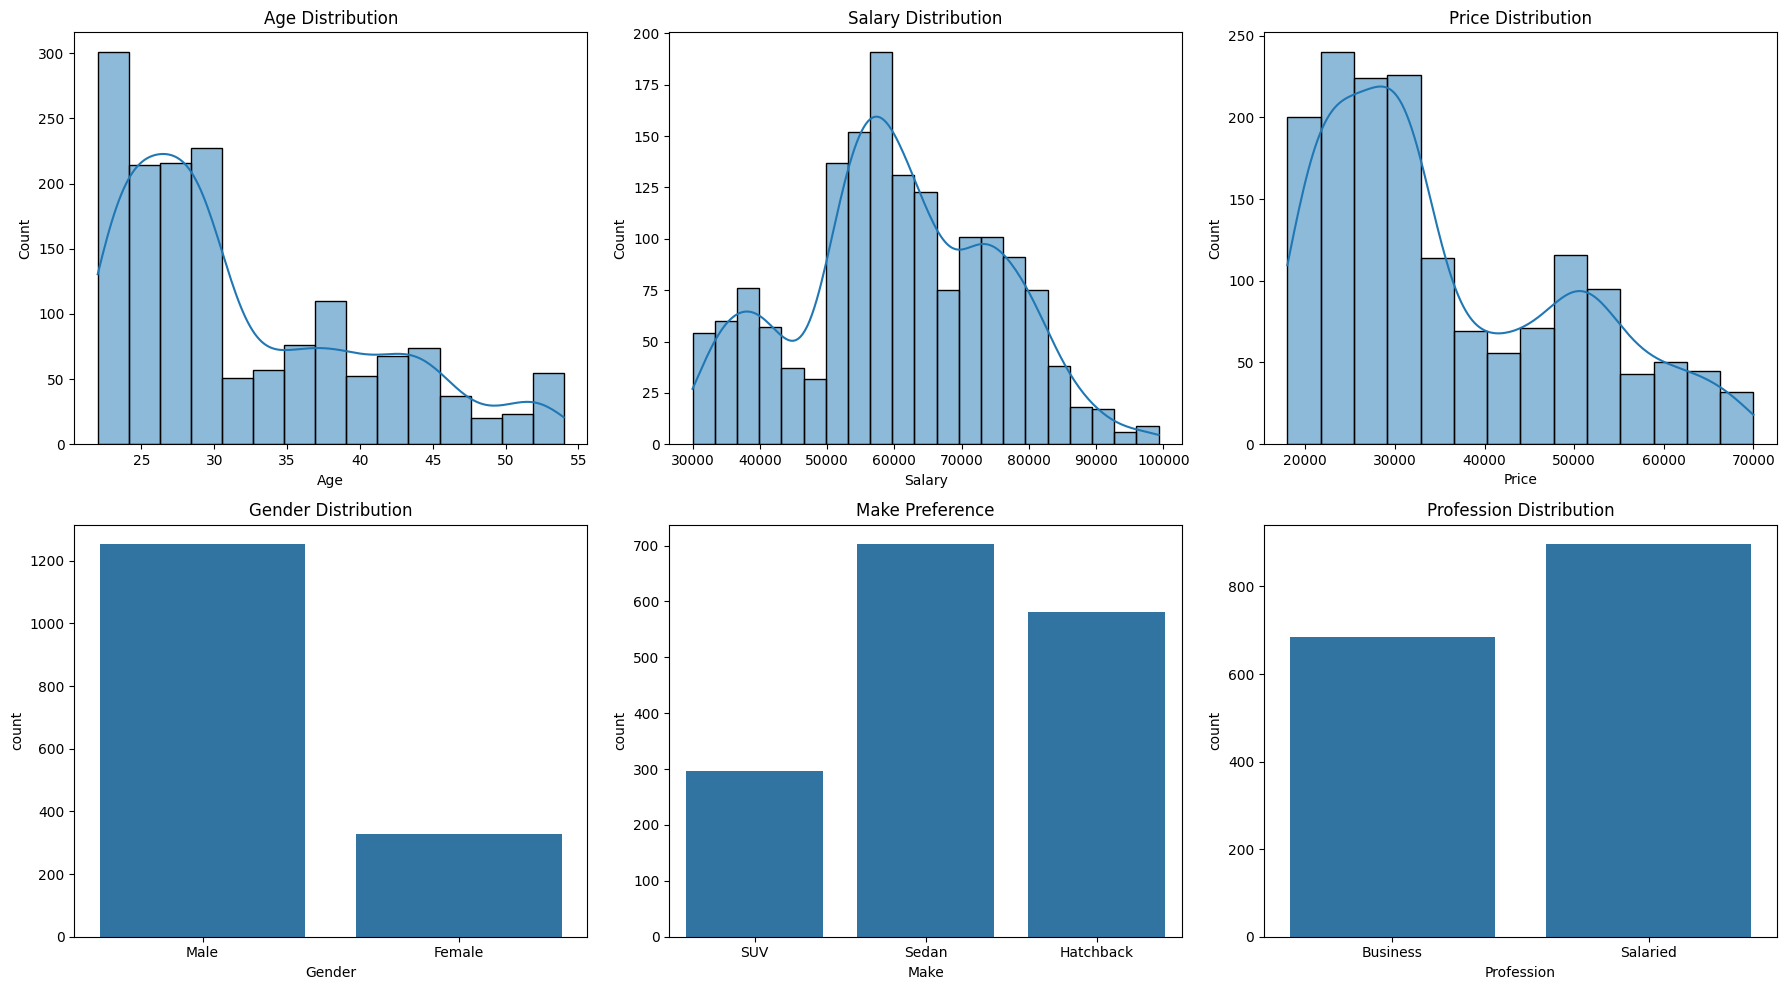

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# Plot distributions for numerical columns and categorial  columns.
sns.histplot(data['Age'], kde=True, ax=axes[0, 0]).set_title('Age Distribution')
sns.histplot(data['Salary'], kde=True, ax=axes[0, 1]).set_title('Salary Distribution')
sns.histplot(data['Price'], kde=True, ax=axes[0, 2]).set_title('Price Distribution')


sns.countplot(data=data, x='Gender', ax=axes[1, 0]).set_title('Gender Distribution')
sns.countplot(data=data, x='Make', ax=axes[1, 1]).set_title('Make Preference')
sns.countplot(data=data, x='Profession', ax=axes[1, 2]).set_title('Profession Distribution')

plt.tight_layout()
plt.show()



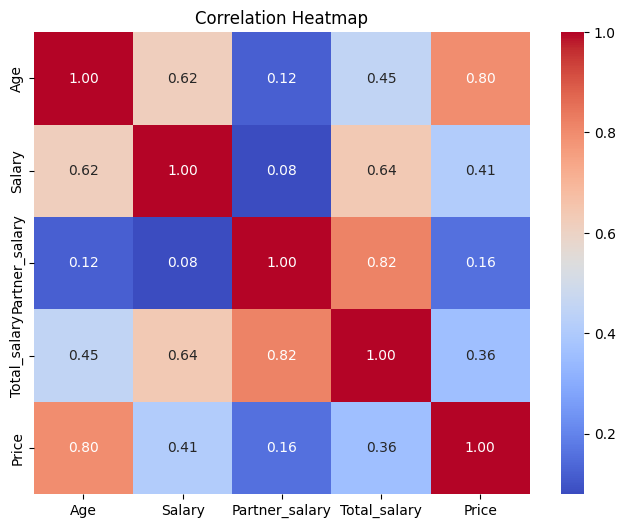

In [27]:
# Bivariate Analysis: Correlation between Numerical Variables
correlation_matrix = data[['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f').set_title('Correlation Heatmap')
plt.show()

###: 1. Do men tend to prefer SUVs more compared to women?


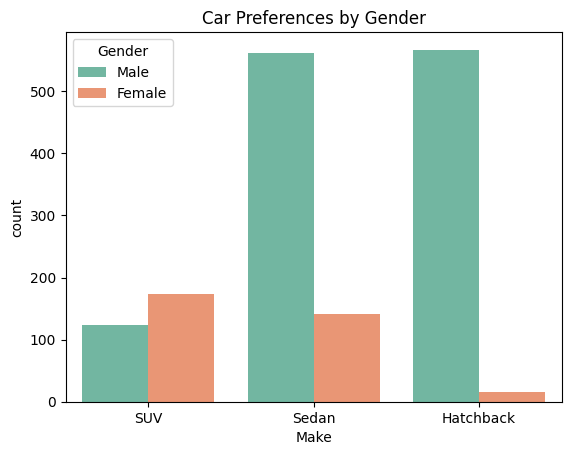

,proportion
Gender,
Female,58.249158
Male,41.750842


In [28]:
# Plot the distribution of car types by gender
sns.countplot(x='Make', hue='Gender', data=data, palette='Set2')
plt.title('Car Preferences by Gender')
plt.show()
suv_preference = data[data['Make'] == 'SUV']['Gender'].value_counts(normalize=True) * 100

suv_preference

#### 2. What is the likelihood of a salaried person buying a Sedan?


Likelihood of a salaried person buying a Sedan: 44.20%


<ipython-input-32-06353ab2bfda>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Make', data=salaried, palette='pastel')


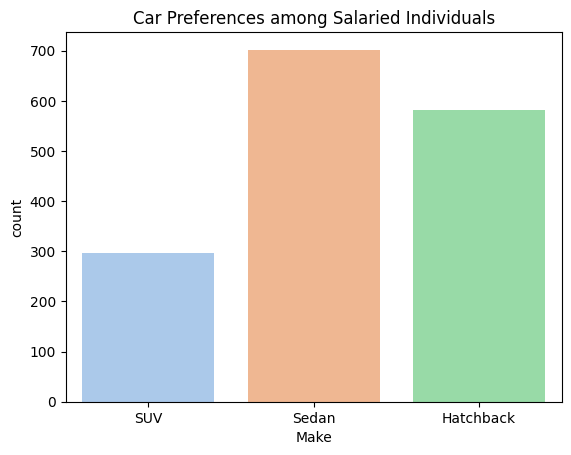

In [32]:
salaried_sedan = data[(data['Profession'] == 'Salaried') & (data['Make'] == 'Sedan')].shape[0]
total_salaried = data[data['Profession'] == 'Salaried'].shape[0]
salaried_sedan_likelihood = (salaried_sedan / total_salaried) * 100
print(f"Likelihood of a salaried person buying a Sedan: {salaried_sedan_likelihood:.2f}%")
salaried = data[data['Salary'] > 0]
sns.countplot(x='Make', data=salaried, palette='pastel')
plt.title('Car Preferences among Salaried Individuals')
plt.show()


### 3. Evidence for Sheldon Cooper's claim (SUV vs Sedan preference among salaried males)


Proportion of SUVs purchased by salaried males: 0.10
Proportion of Sedans purchased by salaried males: 0.45


<ipython-input-38-5980e7f553bf>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Make', data=salaried_males, palette='muted', order=['SUV', 'Sedan'])


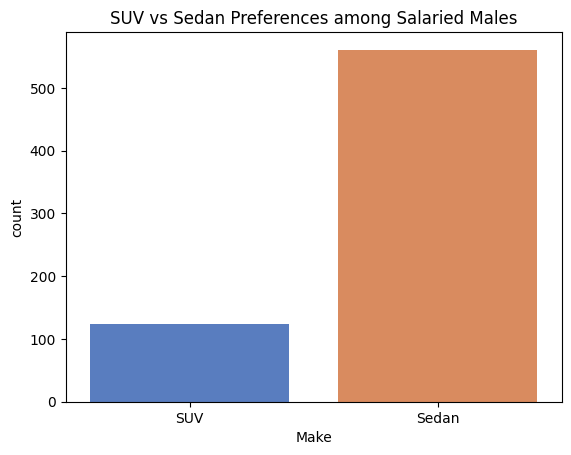

Chi-square test p-value: 1.0000


In [38]:
# salaried_male_suv = data[(data['Profession'] == 'Salaried') & (data['Gender'] == 'Male') & (data['Make'] == 'SUV')].shape[0]
# salaried_male_sedan = data[(data['Profession'] == 'Salaried') & (data['Gender'] == 'Male') & (data['Make'] == 'Sedan')].shape[0]
# suv_vs_sedan_ratio = salaried_male_suv / salaried_male_sedan if salaried_male_sedan != 0 else 'Infinite'
# # suv_vs_sedan_ratio
# print(f"The ratio of SUV to Sedan preferences among salaried males is: {suv_vs_sedan_ratio}")
# Filter salaried males
salaried_males = data[(data['Salary'] > 0) & (data['Gender'] == 'Male')]

# Count SUVs and Sedans purchased by salaried males
suv_count = salaried_males[salaried_males['Make'] == 'SUV'].shape[0]
sedan_count = salaried_males[salaried_males['Make'] == 'Sedan'].shape[0]

# Calculate proportions
total_salaried_males = salaried_males.shape[0]
suv_proportion = suv_count / total_salaried_males
sedan_proportion = sedan_count / total_salaried_males

print(f"Proportion of SUVs purchased by salaried males: {suv_proportion:.2f}")
print(f"Proportion of Sedans purchased by salaried males: {sedan_proportion:.2f}")

# Visualize the data
sns.countplot(x='Make', data=salaried_males, palette='muted', order=['SUV', 'Sedan'])
plt.title('SUV vs Sedan Preferences among Salaried Males')
plt.show()

# Chi-square test to check statistical significance
contingency = [[suv_count, sedan_count]]
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square test p-value: {p:.4f}")

###4. How does the amount spent on purchasing automobiles vary by gender?


   Gender          mean   median       sum
0  Female  47705.167173  49000.0  15695000
1    Male  32416.134185  29000.0  40585000


<ipython-input-41-fc025906dc76>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Price', data=data, palette='pastel')


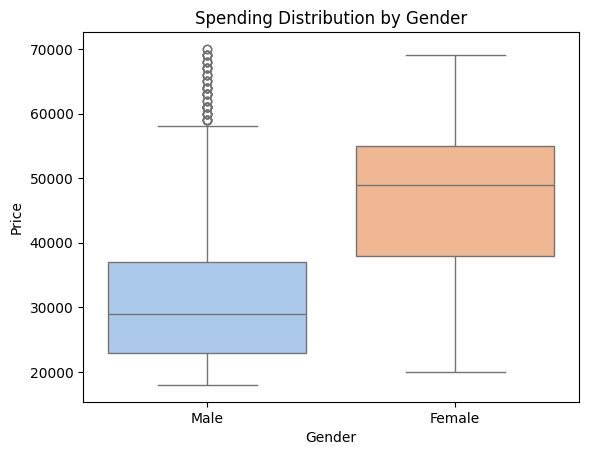

In [41]:
gender_stats = data.groupby('Gender')['Price'].agg(['mean', 'median', 'sum']).reset_index()
print(gender_stats)

# Visualize the spending distribution using a box plot
sns.boxplot(x='Gender', y='Price', data=data, palette='pastel')
plt.title('Spending Distribution by Gender')
plt.show()


###5. How much money was spent on purchasing automobiles by individuals with a personal loan?

Total spending by individuals with personal loans: 27290000
  Personal_loan       sum          mean   median
0            No  28990000  36742.712294  32000.0
1           Yes  27290000  34457.070707  31000.0


<ipython-input-45-aadd09e06e05>:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Personal_loan', y='Price', data=data, estimator=sum, ci=None, palette='Set2')
<ipython-input-45-aadd09e06e05>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Personal_loan', y='Price', data=data, estimator=sum, ci=None, palette='Set2')


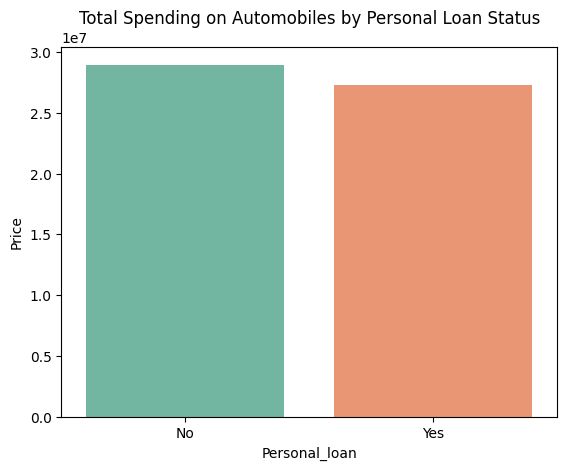

In [45]:
loan_spending = data[data['Personal_loan'] == 'Yes']['Price'].sum()
print(f"Total spending by individuals with personal loans: {loan_spending}")
loan_stats = data.groupby('Personal_loan')['Price'].agg(['sum', 'mean', 'median']).reset_index()
print(loan_stats)

# Visualize total spending by loan status using a bar plot
sns.barplot(x='Personal_loan', y='Price', data=data, estimator=sum, ci=None, palette='Set2')
plt.title('Total Spending on Automobiles by Personal Loan Status')
plt.show()


###6. How does having a working partner influence the purchase of higher-priced cars?

Avg. price with working partner: 35267.28110599078
Avg. price without working partner: 36000.0
  Partner_working          mean   median    max
0              No  36000.000000  31000.0  70000
1             Yes  35267.281106  31000.0  70000


<ipython-input-48-39c75dbf2815>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Partner_working', y='Price', data=data, palette='coolwarm')


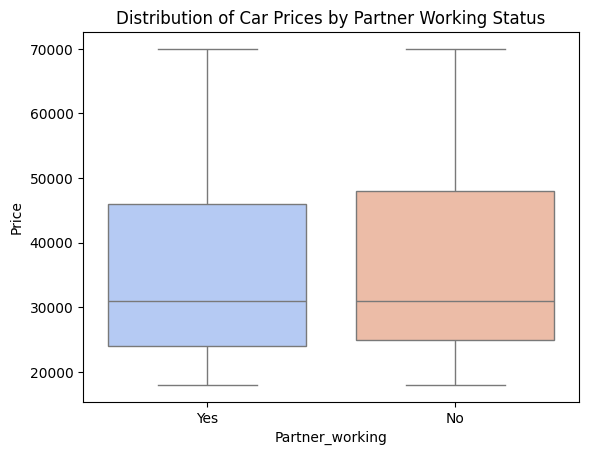

In [48]:
avg_price_working_partner = data[data['Partner_working'] == 'Yes']['Price'].mean()
avg_price_non_working_partner = data[data['Partner_working'] == 'No']['Price'].mean()
print(f"Avg. price with working partner: {avg_price_working_partner}")
print(f"Avg. price without working partner: {avg_price_non_working_partner}")
partner_stats = data.groupby('Partner_working')['Price'].agg(['mean', 'median', 'max']).reset_index()
print(partner_stats)

# Visualize the price distribution with box plot
sns.boxplot(x='Partner_working', y='Price', data=data, palette='coolwarm')
plt.title('Distribution of Car Prices by Partner Working Status')
plt.show()

##Outlier Check:

In [ ]:
# Checking for outliers using boxplots
sns.boxplot(data=data[['Salary', 'Price', 'Age']])
plt.show()


Observations and Insights:
Age and salary distributions are skewed towards younger individuals and mid-range salaries.
No extreme outliers were detected in key numerical variables like Salary or Price.

#Bivariate Analysis

In [ ]:
correlation_matrix = data[['Age', 'Salary', 'Partner_salary', 'Total_salary', 'Price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f').set_title('Correlation Heatmap')
plt.show()


##Categorical vs. Numerical Relationships:

In [ ]:
sns.boxplot(x='Make', y='Price', data=data)
plt.title('Price Variation Across Car Types')
plt.show()


Insights:
Total Salary is highly correlated with individual and partner salaries.
SUVs tend to have higher prices compared to Hatchbacks and Sedans.

car purchase by gender

In [ ]:
sns.countplot(data=data, x='Gender', hue='Make')
plt.title('Car Purchases by Gender')
plt.show()


In [ ]:
sns.boxplot(data=data, y='Price')
plt.title('Price Distribution')
plt.show()


##Bivariate and Multivariate Analysis:
###1. Relationship between Partner Working and Car Price:

In [ ]:
# Group by 'Partner_working' and calculate mean, median of Price
partner_stats = data.groupby('Partner_working')['Price'].agg(['mean', 'median'])
print(partner_stats)

# Visualize the difference using bar plots
sns.barplot(x='Partner_working', y='Price', data=data)
plt.title('Average Price of Car by Partner Working Status')
plt.show()


In [ ]:
import plotly.express as px


fig = px.scatter(data, x='Salary', y='Price', color='Gender',
                 hover_data=['Gender', 'Make'],
                 title='Interactive Scatter Plot of Salary vs Price')
fig.show()


In [ ]:

# Create an interactive bar plot of 'Make' by 'Gender'
fig = px.histogram(data, x='Make', color='Gender', barmode='group',
                   title='SUV Preference by Gender',
                   hover_data=['Make'])

fig.show()
sns.countplot(data=data, x='Gender', hue='Make')
plt.title('Car Purchases by Gender')
plt.show()
# Group by 'Partner_working' and calculate mean, median of Price
partner_stats = data.groupby('Partner_working')['Price'].agg(['mean', 'median'])
print(partner_stats)

# Visualize the difference using bar plots
sns.barplot(x='Partner_working', y='Price', data=data)
plt.title('Average Price of Car by Partner Working Status')
plt.show()
sns.catplot(data=data, x='Gender', hue='Marital_status', col='Make', kind='count')
plt.show()


In [ ]:
filtered_data = data[(data['Gender'] == 'Male') & (data['Salary'] > 0)]
fig = px.histogram(filtered_data, x='Make',
                   title='SUV vs Sedan Purchase by Salaried Males',
                   color='Make', barmode='group')

fig.show()


In [ ]:
filtered_data = data[(data['Gender'] == 'Male') & (data['Salary'] > 0)]
fig = px.histogram(filtered_data, x='Make',
                   title='SUV vs Sedan Purchase by Salaried Males',
                   color='Make', barmode='group')

fig.show()


In [ ]:
fig = sns.boxplot(data, x='Gender', y='Price',
             title='Amount Spent on Cars by Gender',
             points='all')

fig.show()


In [ ]:
fig = px.histogram(data[data['Personal_loan'] == 'Yes'],
                   x='Price', nbins=20,
                   title='Distribution of Amount Spent by Personal Loan Takers')

fig.show()


In [ ]:
fig = px.box(data, x='Partner_working', y='Price',
             title='Car Price vs Partner Working Status',
             points='all', hover_data=['Make', 'Price'])

fig.show()


Univariate Analysis (for Numerical Variables):

In [ ]:
fig = px.histogram(data, x='Salary', nbins=30,
                   title='Salary Distribution',
                   marginal='box', hover_data=['Salary'])
fig.show()


#4. Bivariate Analysis (Numerical vs. Numerical):

In [ ]:
fig = px.scatter(data, x='Salary', y='Price',
                 title='Salary vs Car Price',
                 color='Gender',
                 hover_data=['Make', 'Total_salary'])

fig.show()


##5. Multivariate Analysis (Categorical Variables):


In [ ]:
fig = px.histogram(data, x='Make', color='Marital_status',
                   barmode='group', facet_col='Gender',
                   title='Car Make by Marital Status and Gender',
                   hover_data=['Price'])

fig.show()
# Checking for outliers using boxplots
sns.boxplot(data=data[['Salary', 'Price', 'Age']])
plt.show()
